📌 Step 1: Dataset Preparation

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Simulated Dataset
students_iq = np.random.randint(80,150, size=100)
students_cgpa = np.random.uniform(1.0, 10.0, size=100)
students_pass_fail = np.where(
    (students_iq > 70) & (students_cgpa > 7.5),
    np.random.choice([1, 0], size=100, p=[0.85, 0.15]),  # mostly pass if both conditions met
    np.random.choice([1, 0], size=100, p=[0.3, 0.7])     # mostly fail otherwise
)

students_data = pd.DataFrame({
    'IQ': students_iq,
    'CGPA': students_cgpa,
    'Pass/Fail': students_pass_fail
})
students_data.head()

,IQ,CGPA,Pass/Fail
0,125,6.741647,0
1,88,3.311955,1
2,82,6.688139,0
3,105,1.526092,0
4,127,2.275970,0


In [15]:
students_data['Pass/Fail'].value_counts()

Pass/Fail
0    57
1    43
Name: count, dtype: int64

In [16]:
## Feature Matrix and label
X = students_data[['IQ', 'CGPA']].values
y = students_data['Pass/Fail'].values.reshape(-1,1)

## Normalize Features
scaler = StandardScaler()
X = scaler.fit_transform(X)

📌 Step 2: Simple Perceptron Implementation

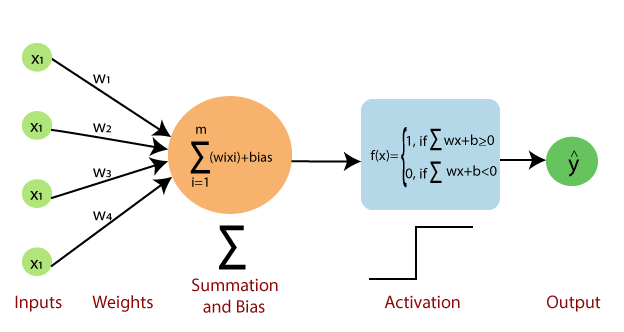

In [ ]:
class SimplePerceptron:
    def __init__(self, input_dim, lr=0.01):
        self.w = np.random.randn(input_dim, 1) * 0.01
        self.bias = 0.0
        self.lr = lr
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def forward(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.bias)
    
    def compute_loss(self, y_hat, y):
        ## Binary Cross-Entropy Loss
        loss = - (y * np.log(y_hat + 1e-08) + (1 - y) * np.log(1 - y_hat + 1e-8))
        return np.mean(loss)
    
    def train(self, X, y, epochs=100):
        for epoch in range(epochs):
            y_hat = self.forward(X)
            loss = self.compute_loss(y_hat, y)
            
            ## Backward Propagation
            n_samples = X.shape[0]
            dw = (1 / n_samples) * np.dot(X.T, (y_hat - y))
            db = (1 / n_samples) * np.sum((y_hat - y))

            ## Update the Weights & Bias
            self.w = self.w - self.lr * dw
            self.bias = self.bias - self.lr * db

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch} - Loss: {loss:.4f}")
        
        return self.w, self.bias

    def predict(self, X):
        return (self.forward(X) > 0.5).astype('int')

📌 Step 3: Train Custom Model

In [39]:
# Train custom perceptron
model = SimplePerceptron(input_dim=2, lr=0.01)
w, b = model.train(X, y, epochs=500)
print("\nCustom Perceptron")
print("Weights:", w.ravel())
print("Bias:", b)

Epoch 0 - Loss: 0.6936
Epoch 10 - Loss: 0.6902
Epoch 20 - Loss: 0.6870
Epoch 30 - Loss: 0.6839
Epoch 40 - Loss: 0.6809
Epoch 50 - Loss: 0.6781
Epoch 60 - Loss: 0.6755
Epoch 70 - Loss: 0.6730
Epoch 80 - Loss: 0.6705
Epoch 90 - Loss: 0.6683
Epoch 100 - Loss: 0.6661
Epoch 110 - Loss: 0.6640
Epoch 120 - Loss: 0.6620
Epoch 130 - Loss: 0.6601
Epoch 140 - Loss: 0.6583
Epoch 150 - Loss: 0.6566
Epoch 160 - Loss: 0.6550
Epoch 170 - Loss: 0.6534
Epoch 180 - Loss: 0.6520
Epoch 190 - Loss: 0.6506
Epoch 200 - Loss: 0.6492
Epoch 210 - Loss: 0.6479
Epoch 220 - Loss: 0.6467
Epoch 230 - Loss: 0.6455
Epoch 240 - Loss: 0.6444
Epoch 250 - Loss: 0.6434
Epoch 260 - Loss: 0.6424
Epoch 270 - Loss: 0.6414
Epoch 280 - Loss: 0.6405
Epoch 290 - Loss: 0.6396
Epoch 300 - Loss: 0.6388
Epoch 310 - Loss: 0.6380
Epoch 320 - Loss: 0.6372
Epoch 330 - Loss: 0.6365
Epoch 340 - Loss: 0.6358
Epoch 350 - Loss: 0.6351
Epoch 360 - Loss: 0.6345
Epoch 370 - Loss: 0.6339
Epoch 380 - Loss: 0.6333
Epoch 390 - Loss: 0.6327
Epoch 400 -

📌 Step 4: Compare with scikit-learn Perceptron

In [40]:
sk_model = SklearnPerceptron(max_iter=1000, eta0=0.1, random_state=42, tol=1e-3)
sk_model.fit(X, y.ravel())

print("\nSklearn Perceptron")
print("Weights:", sk_model.coef_)
print("Bias:", sk_model.intercept_)


Sklearn Perceptron
Weights: [[-0.09259306 -0.01651243]]
Bias: [0.1]


📌 Predictions & Accuracy

In [41]:
custom_preds = model.predict(X)
custom_acc = accuracy_score(y, custom_preds)

## SkLearn Perceptron Predictions
sk_preds = sk_model.predict(X)
sk_acc = accuracy_score(y.ravel(), sk_preds)

print("\n✅ Accuracy Comparision")
print(f"\nCustom Perceptron Accuracy: {custom_acc}")
print(f"\nSklearn Perceptron Accurcay: {sk_acc}")


✅ Accuracy Comparision

Custom Perceptron Accuracy: 0.67

Sklearn Perceptron Accurcay: 0.48
